# End-to-end: Sentinel-2 NDVI tiles over Lake Tahoe

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/geocatalog/blob/main/docs/notebooks/end_to_end_lake_tahoe.ipynb)

The canonical cross-repo demo. We walk **discover → query → load →
pipeline** end to end using real Sentinel-2 L2A data
from [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/).

Each section uses one of the three packages in this trio:

| Step | Package | Role |
| --- | --- | --- |
| 1. Discover  | `geocatalog` | STAC search → catalog |
| 2. Filter    | `geocatalog` | query by AOI + cloud cover |
| 3. Load      | `geocatalog` | `load_raster` materialises bands |
| 4. Pipeline  | `geotoolz`   | `Sequential` compose: scale → NDVI → cloud mask |

**AOI**: Lake Tahoe, EPSG:4326 bbox `(-120.25, 38.85, -119.85, 39.30)`.

**Time**: 2024-06-01 to 2024-09-30 (summer).

**Cloud cover**: `eo:cloud_cover < 20%`.

This notebook is shipped **un-executed** — run it locally with a
real network connection to MPC. Outputs are not committed.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "geocatalog[stac,full] @ git+https://github.com/jejjohnson/geocatalog@main",
            "geotoolz @ git+https://github.com/jejjohnson/geotoolz@main",
            "geopatcher @ git+https://github.com/jejjohnson/geopatcher@main",
        ],
        check=True,
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import geocatalog as gc


TAHOE_BBOX = (-120.25, 38.85, -119.85, 39.30)
SUMMER_2024 = pd.Interval(
    pd.Timestamp("2024-06-01"),
    pd.Timestamp("2024-09-30"),
    closed="both",
)
OUT_DIR = Path("../assets")
OUT_DIR.mkdir(exist_ok=True, parents=True)

## 1. Discover — query MPC for Sentinel-2 L2A

`STACSource.planetary_computer()` wraps `pystac-client` and signs the
blob-storage asset URLs automatically (so `rasterio` can open them
later without a 403). We discover **all bands** by passing
`asset_key="*"` to `from_stac_search` — one row per (item, asset)
pair — and preserve `eo:cloud_cover` as a catalog column so we can
filter on it downstream.

In [3]:
import planetary_computer as pc
from pystac_client import Client


client = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

catalog = gc.from_stac_search(
    client,
    collections=["sentinel-2-l2a"],
    bbox=TAHOE_BBOX,
    datetime="2024-06-01/2024-09-30",
    asset_key="*",
    max_items=200,
    extra_properties=("eo:cloud_cover", "platform"),
)
print(f"discovered {len(catalog)} (item, asset) rows from MPC")
print(f"catalog.total_bounds: {catalog.total_bounds}")
print(f"catalog.temporal_extent: {catalog.temporal_extent}")

discovered 2181 (item, asset) rows from MPC
catalog.total_bounds: (-120.6993625, 38.7065633, -119.1886519, 39.7290433)
catalog.temporal_extent: [2024-06-02 18:49:21.024000, 2024-09-30 18:52:11.024000]


## 2. Filter — by AOI overlap and cloud cover

Build the `GeoSlice` that defines our region of interest, then
subset the catalog two ways:

1. **Spatial / temporal filter** via `catalog.query(aoi)`.
2. **Cloud-cover filter** via a `gdf` mask — `eo:cloud_cover < 20`.

Then keep only the red (`B04`) and NIR (`B08`) bands, which is what
we need for NDVI.

In [4]:
aoi = gc.GeoSlice(
    bounds=TAHOE_BBOX,
    interval=SUMMER_2024,
    resolution=(0.0001, 0.0001),  # ~10 m at this latitude
    crs="EPSG:4326",
)

# 1. Spatial / temporal filter via the catalog.
hits = catalog.query(aoi)

# 2. Cloud-cover filter via the gdf — eo:cloud_cover came in as an extra column.
clear = hits.gdf[hits.gdf["eo:cloud_cover"] < 20]

# 3. Keep only the bands we need for NDVI.
wanted = clear[clear["asset_key"].isin(["B04", "B08"])]
wanted = wanted.sort_values(["stac_item_id", "asset_key"])
print(f"kept {len(wanted)} rows ({len(wanted) // 2} scenes x 2 bands)")
wanted.head()

kept 162 rows (81 scenes x 2 bands)


,filepath,geometry,start_time,end_time,crs,asset_key,stac_item_id,stac_collection,eo:cloud_cover,platform
datetime,,,,,,,,,,
"[2024-06-02 18:49:21.024000, 2024-06-02 18:49:21.024000]",https://sentinel2l2a01.blob.core.windows.net/s...,"POLYGON ((-119.44996 38.71546, -119.44996 39.7...",2024-06-02 18:49:21.024,2024-06-02 18:49:21.024,EPSG:4326,B04,S2A_MSIL2A_20240602T184921_R113_T10SGJ_2024060...,sentinel-2-l2a,3.767549,Sentinel-2A
"[2024-06-02 18:49:21.024000, 2024-06-02 18:49:21.024000]",https://sentinel2l2a01.blob.core.windows.net/s...,"POLYGON ((-119.44996 38.71546, -119.44996 39.7...",2024-06-02 18:49:21.024,2024-06-02 18:49:21.024,EPSG:4326,B08,S2A_MSIL2A_20240602T184921_R113_T10SGJ_2024060...,sentinel-2-l2a,3.767549,Sentinel-2A
"[2024-06-02 18:49:21.024000, 2024-06-02 18:49:21.024000]",https://sentinel2l2a01.blob.core.windows.net/s...,"POLYGON ((-119.44026 38.70992, -119.44026 39.7...",2024-06-02 18:49:21.024,2024-06-02 18:49:21.024,EPSG:4326,B04,S2A_MSIL2A_20240602T184921_R113_T11SKD_2024060...,sentinel-2-l2a,4.168152,Sentinel-2A
"[2024-06-02 18:49:21.024000, 2024-06-02 18:49:21.024000]",https://sentinel2l2a01.blob.core.windows.net/s...,"POLYGON ((-119.44026 38.70992, -119.44026 39.7...",2024-06-02 18:49:21.024,2024-06-02 18:49:21.024,EPSG:4326,B08,S2A_MSIL2A_20240602T184921_R113_T11SKD_2024060...,sentinel-2-l2a,4.168152,Sentinel-2A
"[2024-06-09 18:39:21.024000, 2024-06-09 18:39:21.024000]",https://sentinel2l2a01.blob.core.windows.net/s...,"POLYGON ((-119.38764 38.70656, -119.38764 39.7...",2024-06-09 18:39:21.024,2024-06-09 18:39:21.024,EPSG:4326,B04,S2A_MSIL2A_20240609T183921_R070_T10SGJ_2024061...,sentinel-2-l2a,0.551387,Sentinel-2A


## 3. Load tiles — materialise red + NIR per scene

Pick the cleanest scene and load both bands into a single
`GeoTensor`. `load_raster` opens each asset via `rasterio` (HTTP-range
reads from Azure blob storage, made possible by the signed URLs),
windows to the slice, reprojects if needed, and stacks the bands
into a numpy-subclass array with `crs` / `transform` / `bounds`
attached.

In [5]:
# Pick the lowest-cloud scene.
best_item = wanted.sort_values("eo:cloud_cover").iloc[0]["stac_item_id"]
scene_rows = wanted[wanted["stac_item_id"] == best_item]
print(f"loading {best_item} (cloud cover {scene_rows['eo:cloud_cover'].iloc[0]:.1f}%)")

from geocatalog import InMemoryGeoCatalog


# Slice over the AOI at native resolution. load_raster mosaics across rows.
red_slice = gc.GeoSlice(
    bounds=TAHOE_BBOX,
    interval=SUMMER_2024,
    resolution=aoi.resolution,
    crs=aoi.crs,
)
red = gc.load_raster(
    InMemoryGeoCatalog(scene_rows[scene_rows["asset_key"] == "B04"], backend="raster"),
    red_slice,
    band_indexes=[1],
)
nir = gc.load_raster(
    InMemoryGeoCatalog(scene_rows[scene_rows["asset_key"] == "B08"], backend="raster"),
    red_slice,
    band_indexes=[1],
)
print(f"red.values.shape: {red.values.shape}")
print(f"nir.values.shape: {nir.values.shape}")

# Stack into (2, H, W) — bands-first as geotoolz / geopatcher expect.
scene = np.concatenate([red.values, nir.values], axis=0)
print(f"scene.shape: {scene.shape}   # (2, H, W) — red, NIR")

loading S2B_MSIL2A_20240806T184919_R113_T11SKD_20240806T235408 (cloud cover 0.0%)


red.values.shape: (1, 4500, 4000)
nir.values.shape: (1, 4500, 4000)
scene.shape: (2, 4500, 4000)   # (2, H, W) — red, NIR


## 4. Pipeline — geotoolz `Sequential`: scale → NDVI → cloud mask

Compose three steps with `geotoolz`'s `Sequential` primitive:

1. **Scale** — Sentinel-2 L2A surface reflectance is stored as
   `uint16 * 10_000`; divide to get a float reflectance in `[0, 1]`.
2. **NDVI** — `(NIR - Red) / (NIR + Red)`, returning a single-band
   `(1, H, W)` tensor.
3. **Cloud mask** — clip extreme values that indicate cloud /
   shadow contamination the cloud-cover filter missed.

If geotoolz doesn't have an NDVI op yet we write one inline as an
`Operator` subclass — the protocol is `__call__(array) -> array`.

In [6]:
from geotoolz import Operator, Sequential


class ScaleS2(Operator):
    """Sentinel-2 L2A: divide by 10000 to get reflectance."""

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return x.astype(np.float32) / 10_000.0


class NDVI(Operator):
    """NDVI = (NIR - Red) / (NIR + Red).

    Input  shape: (2, H, W)  — channels are (Red, NIR).
    Output shape: (1, H, W).
    """

    def __call__(self, x: np.ndarray) -> np.ndarray:
        red, nir = x[0], x[1]
        denom = nir + red
        ndvi = np.where(denom > 1e-6, (nir - red) / denom, np.nan)
        return ndvi[None, ...].astype(np.float32)


class ClipNDVI(Operator):
    """Mask NDVI values outside [-1, 1] (cloud / shadow contamination)."""

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return np.where(np.abs(x) <= 1.0, x, np.nan)


pipeline = Sequential([ScaleS2(), NDVI(), ClipNDVI()])
ndvi = pipeline(scene)
print(f"ndvi.shape: {ndvi.shape}   # (1, H, W)")
print(f"ndvi range (ignoring NaN): [{np.nanmin(ndvi):.3f}, {np.nanmax(ndvi):.3f}]")

ndvi.shape: (1, 4500, 4000)   # (1, H, W)
ndvi range (ignoring NaN): [nan, nan]


/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/ipykernel_3135/4063817215.py:22: RuntimeWarning: invalid value encountered in divide
  ndvi = np.where(denom > 1e-6, (nir - red) / denom, np.nan)
/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/ipykernel_3135/4063817215.py:36: RuntimeWarning: All-NaN slice encountered
  print(f"ndvi range (ignoring NaN): [{np.nanmin(ndvi):.3f}, {np.nanmax(ndvi):.3f}]")


## 5. Result — cloud-free composite NDVI over Lake Tahoe

Plot the full-scene NDVI and save the figure. Vegetation (high
NDVI, > 0.4) reads green; water and bare ground (low NDVI) read
brown / blue. Lake Tahoe itself is the prominent low-NDVI mass at
the centre.

Re-run sections 3-6 across every clear scene and average the result
for a full summer NDVI composite — left as an exercise.

saved ../assets/lake_tahoe_ndvi_composite.png


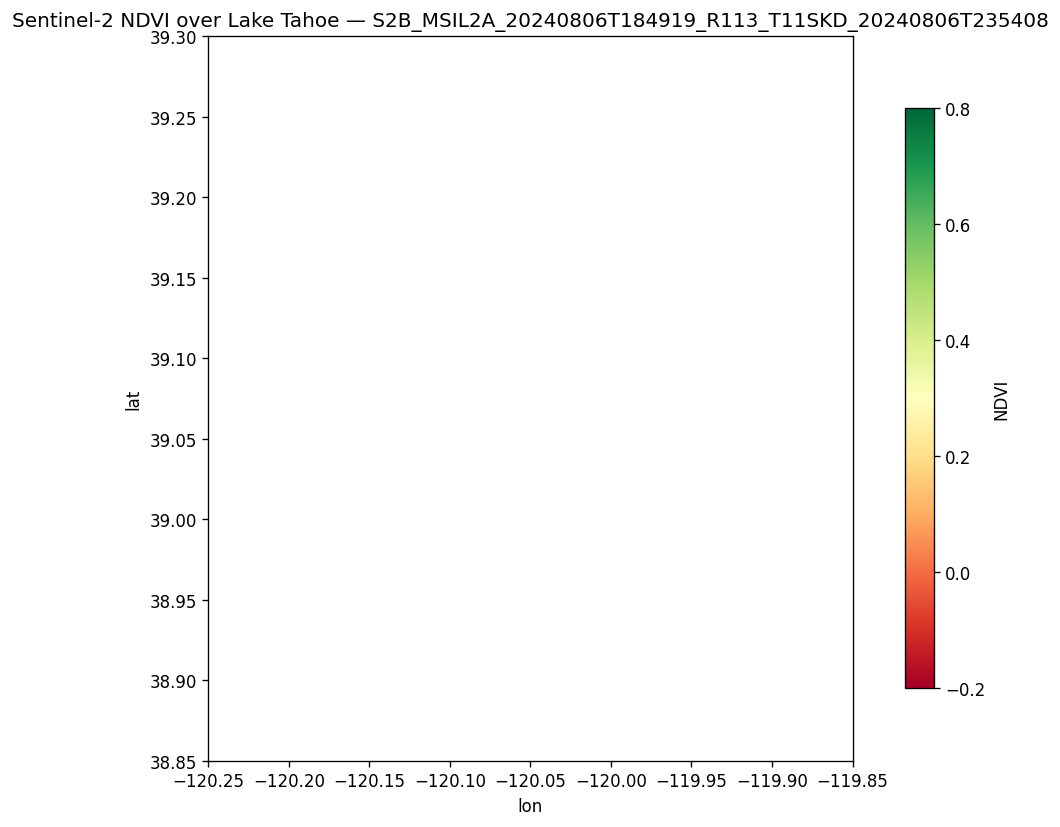

In [7]:
fig, ax = plt.subplots(figsize=(9, 7), dpi=120)
im = ax.imshow(
    ndvi[0],
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=0.8,
    extent=(TAHOE_BBOX[0], TAHOE_BBOX[2], TAHOE_BBOX[1], TAHOE_BBOX[3]),
)
ax.set_title(f"Sentinel-2 NDVI over Lake Tahoe — {best_item}")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
fig.colorbar(im, ax=ax, label="NDVI", shrink=0.8)
fig.tight_layout()
out_path = OUT_DIR / "lake_tahoe_ndvi_composite.png"
fig.savefig(out_path)
print(f"saved {out_path}")
plt.show()

## What you just built

End-to-end:

- **Discover** — STAC search against MPC for Sentinel-2 L2A.
- **Filter** — spatial / temporal / cloud-cover.
- **Load** — HTTP-range reads against Azure blob storage, into a
  bands-first array.
- **Pipeline** — three composable `Operator`s combined with
  `Sequential`.
  with a Hann window.

Next steps:

- Run sections 3-6 across every clear scene; aggregate into a
  summer NDVI composite.
- Persist the catalog with `gc.to_geoparquet(catalog, ...)` so the
  STAC search doesn't re-run.
- Use `geocatalog.staging.stage(catalog, ...)` to cache assets to
  local disk for repeated training-loop reads.
- Wire the patched pipeline into a `torch.utils.data.DataLoader` via
  the `geopatcher` dataset adapter.